In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import LocalOutlierFactor

from sklearn.svm import OneClassSVM

from sklearn.cluster import DBSCAN

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import mlflow
import mlflow.sklearn

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Explore Dataset
print(df.shape)

print(df.info())

print(df.describe())

print(df["Class"].value_counts())

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [5]:
#Statistical Analysis
#Z-Score Method
numerical_columns = df.select_dtypes(include=np.number).columns

X = df[numerical_columns].drop("Class", axis=1)

z_scores = np.abs(zscore(X))

threshold = 3

zscore_anomalies = (z_scores > threshold).any(axis=1)

df["ZScore_Anomaly"] = zscore_anomalies

print("Z-Score anomalies detected:")
print(df["ZScore_Anomaly"].sum())

Z-Score anomalies detected:
37816


In [6]:
#IQR Statistical Method
Q1 = X.quantile(0.25)

Q3 = X.quantile(0.75)

IQR = Q3 - Q1

iqr_anomalies = (
    ((X < (Q1 - 1.5 * IQR)) |
     (X > (Q3 + 1.5 * IQR)))
).any(axis=1)

df["IQR_Anomaly"] = iqr_anomalies

print("IQR anomalies detected:")
print(df["IQR_Anomaly"].sum())

IQR anomalies detected:
138473


In [7]:
#feature scaling
y = df["Class"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
#Convert Labels
# 0 -> 1 (normal)
# 1 -> -1 (anomaly)

y_converted = y.map({0: 1, 1: -1})

In [9]:
#Define Models
models = {

    "LogisticRegression": LogisticRegression(),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "IsolationForest": IsolationForest(
        contamination=0.05,
        random_state=42
    ),

    "LocalOutlierFactor": LocalOutlierFactor(
        contamination=0.05
    ),

    "OneClassSVM": OneClassSVM(
        nu=0.05,
        kernel="rbf"
    ),

    "DBSCAN": DBSCAN(
        eps=3,
        min_samples=10
    )
}

In [ ]:
#MLflow Experiment
mlflow.set_experiment("Advanced_Anomaly_Detection_mlflow")

2026/05/16 13:29:47 INFO mlflow.tracking.fluent: Experiment with name 'Advanced_Anomaly_Detection_mlflow' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/tessa/OneDrive/Documents/anomaly_detection/mlruns/2', creation_time=1778918387695, experiment_id='2', last_update_time=1778918387695, lifecycle_stage='active', name='Advanced_Anomaly_Detection_mlflow', tags={}, trace_location=None, workspace='default'>

In [13]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    with mlflow.start_run(run_name=name):

        # Supervised Models
        if name in ["LogisticRegression", "RandomForest"]:

            model.fit(X_scaled, y)

            predictions = model.predict(X_scaled)

            # Convert to anomaly format
            predictions = np.where(predictions == 1, -1, 1)

        # LOF
        elif name == "LocalOutlierFactor":

            predictions = model.fit_predict(X_scaled)

        # DBSCAN
        elif name == "DBSCAN":

            predictions = model.fit_predict(X_scaled)

            predictions = np.where(predictions == -1, -1, 1)

        # Other unsupervised models
        else:

            model.fit(X_scaled)

            predictions = model.predict(X_scaled)

        # Metrics
        accuracy = accuracy_score(y_converted, predictions)

        precision = precision_score(
            y_converted,
            predictions,
            pos_label=-1
        )

        recall = recall_score(
            y_converted,
            predictions,
            pos_label=-1
        )

        f1 = f1_score(
            y_converted,
            predictions,
            pos_label=-1
        )

        # Store Results
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

        # MLflow Logging
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        print(f"{name} completed.")


Training LogisticRegression...
LogisticRegression completed.

Training RandomForest...
RandomForest completed.

Training IsolationForest...
IsolationForest completed.

Training LocalOutlierFactor...
LocalOutlierFactor completed.

Training OneClassSVM...
OneClassSVM completed.

Training DBSCAN...
DBSCAN completed.


In [ ]:
#compare results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

                Model  Accuracy  Precision    Recall  F1 Score
1        RandomForest  1.000000   1.000000  1.000000  1.000000
0  LogisticRegression  0.999192   0.880814  0.615854  0.724880
4         OneClassSVM  0.951321   0.030346  0.878049  0.058664
2     IsolationForest  0.951199   0.029282  0.847561  0.056608
5              DBSCAN  0.924184   0.019624  0.876016  0.038388
3  LocalOutlierFactor  0.948671   0.004003  0.115854  0.007738


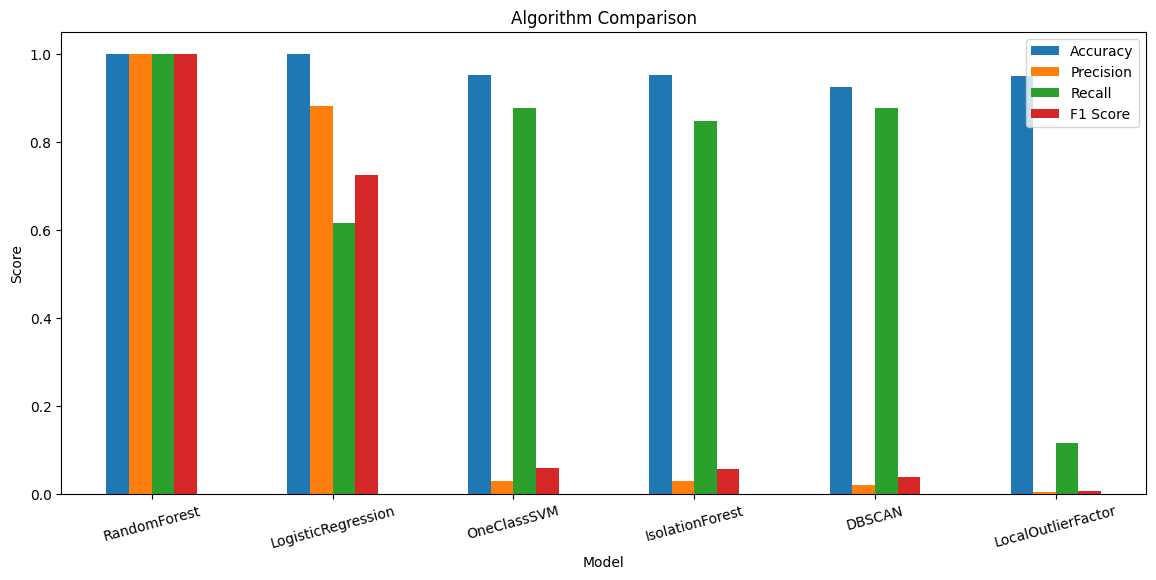

In [15]:
#visualization
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(14,6)
)

plt.title("Algorithm Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

In [16]:
best_model = results_df.iloc[0]

print("\nBest Model:")

print(best_model)


Best Model:
Model        RandomForest
Accuracy              1.0
Precision             1.0
Recall                1.0
F1 Score              1.0
Name: 1, dtype: object


In [29]:
best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

best_model.fit(X_scaled, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
import joblib

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [31]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [32]:
loaded_model = joblib.load("best_model.pkl")

loaded_scaler = joblib.load("scaler.pkl")

In [33]:
new_data = [[
    0.0,     # Time
    -1.35,   # V1
    -0.07,   # V2
    2.53,    # V3
    1.37,    # V4
    -0.33,   # V5
    0.46,    # V6
    0.23,    # V7
    0.09,    # V8
    0.36,    # V9
    0.09,    # V10
    -0.55,   # V11
    -0.61,   # V12
    -0.99,   # V13
    -0.31,   # V14
    1.46,    # V15
    -0.47,   # V16
    0.20,    # V17
    0.02,    # V18
    0.40,    # V19
    0.25,    # V20
    -0.01,   # V21
    0.27,    # V22
    -0.11,   # V23
    0.06,    # V24
    0.12,    # V25
    -0.18,   # V26
    0.13,    # V27
    -0.02,   # V28
    149.62   # Amount
]]

In [34]:
new_data_scaled = loaded_scaler.transform(new_data)

In [35]:
prediction = loaded_model.predict(new_data_scaled)

print(prediction)

[0]


In [36]:
if prediction[0] == 1:
    print("⚠️ Fraudulent Transaction Detected")
else:
    print("✅ Normal Transaction")

✅ Normal Transaction


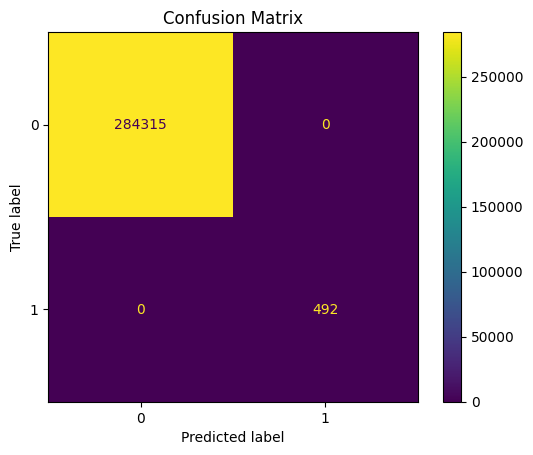

In [38]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

predictions = best_model.predict(X_scaled)

cm = confusion_matrix(y, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(
    y,
    best_model.predict(X_scaled)
)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 1.0
